In [ ]:
#Impact of Personalized Product Recommendations on E-Commerce Purchase Decisions

In [2]:
import os

os.listdir()

['.git',
 'analysis.ipynb',
 'Customer_Transactions.csv',
 'README.md',
 'research_paper.md']

In [6]:
import os

print("Current Folder:")
print(os.getcwd())

print("\nFiles in Folder:")
print(os.listdir())

Current Folder:
c:\Users\ashen\CIS-3032_E-Commerce-Research

Files in Folder:
['.git', 'analysis.ipynb', 'README.md', 'research_paper.md']


In [7]:
import os

print("Current Folder:")
print(os.getcwd())

print("\nFiles in Folder:")
print(os.listdir())

Current Folder:
c:\Users\ashen\CIS-3032_E-Commerce-Research

Files in Folder:
['.git', 'analysis.ipynb', 'Customer_Transactions.csv', 'README.md', 'research_paper.md']


In [8]:
df = pd.read_csv(r"C:\Users\ashen\CIS-3032_E-Commerce-Research\Customer_Transactions.csv")

In [9]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\ashen\CIS-3032_E-Commerce-Research
['.git', 'analysis.ipynb', 'Customer_Transactions.csv', 'README.md', 'research_paper.md']


In [10]:
print(df.shape)

print(df.columns)

print(df.info())

print(df.isnull().sum())

(10000, 14)
Index(['customer_id', 'age', 'gender', 'country', 'annual_income',
       'spending_score', 'num_purchases', 'avg_purchase_value',
       'membership_years', 'website_visits_per_month', 'cart_abandon_rate',
       'churned', 'feedback_text', 'last_purchase_date'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   age                       10000 non-null  int64  
 2   gender                    10000 non-null  str    
 3   country                   10000 non-null  str    
 4   annual_income             10000 non-null  int64  
 5   spending_score            10000 non-null  int64  
 6   num_purchases             10000 non-null  int64  
 7   avg_purchase_value        10000 non-null  float64
 8   membership_years          10000 non-null  int64  
 9

In [11]:
df = df.drop_duplicates()

print(df.shape)

(10000, 14)


In [12]:
df['last_purchase_date'] = pd.to_datetime(df['last_purchase_date'])

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['gender'] = le.fit_transform(df['gender'])

df['country'] = le.fit_transform(df['country'])

In [14]:
import numpy as np

df['purchase_decision'] = np.where(
    df['num_purchases'] > 0,
    1,
    0
)

df['purchase_decision'].value_counts()

purchase_decision
1    10000
Name: count, dtype: int64

In [15]:
features = [
    'age',
    'annual_income',
    'spending_score',
    'avg_purchase_value',
    'membership_years',
    'website_visits_per_month',
    'cart_abandon_rate'
]

X = df[features]

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [17]:
#K-Means Clustering
#Elbow Method

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_scaled)

    inertia.append(km.inertia_)

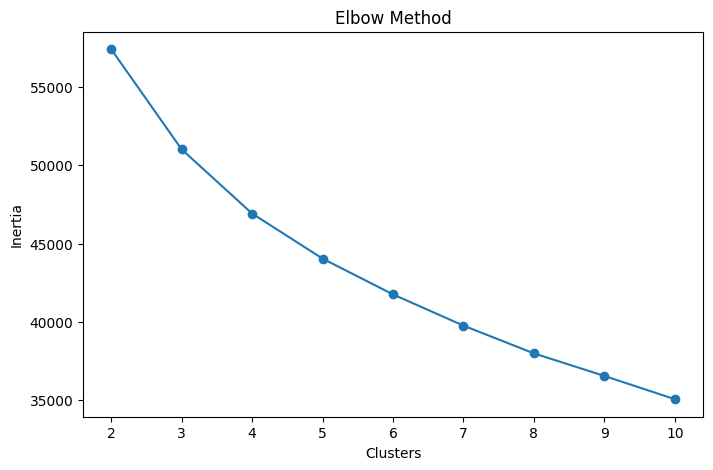

In [18]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), inertia, marker='o')

plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [19]:
#Silhouette Score

from sklearn.metrics import silhouette_score

for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print("K =", k,
          "Score =", round(score,4))

K = 2 Score = 0.1657
K = 3 Score = 0.1447
K = 4 Score = 0.1333
K = 5 Score = 0.1286
K = 6 Score = 0.1263
K = 7 Score = 0.1269
K = 8 Score = 0.128
K = 9 Score = 0.1305
K = 10 Score = 0.1327


In [20]:
best_k = 4

In [21]:
#Final Clustering

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

In [22]:
cluster_profile = df.groupby('Cluster')[features].mean()

print(cluster_profile)

               age  annual_income  spending_score  avg_purchase_value  \
Cluster                                                                 
0        27.212942   73775.789315       50.554929           44.588194   
1        49.635915   68360.576689       23.388003           37.199875   
2        50.997865   66617.386849       75.686593           49.051336   
3        49.851226  138842.364328       57.483094           60.480423   

         membership_years  website_visits_per_month  cart_abandon_rate  
Cluster                                                                 
0                2.110986                 15.846501           0.489793  
1                7.827259                 15.618831           0.509115  
2                8.744663                 15.282237           0.505798  
3                7.057058                 15.524091           0.500719  


In [23]:
#Logistic Regression

X = df[features]

y = df['purchase_decision']

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [25]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [27]:
df['purchase_decision'].value_counts()

purchase_decision
1    10000
Name: count, dtype: int64

In [28]:
df['purchase_decision'] = np.where(
    df['num_purchases'] > 0,
    1,
    0
)

In [30]:
print(df['num_purchases'].describe())

print(df['num_purchases'].min())

print(df['num_purchases'].value_counts().head())

count    10000.000000
mean        22.576000
std         10.163639
min          1.000000
25%         14.000000
50%         22.000000
75%         31.000000
max         49.000000
Name: num_purchases, dtype: float64
1
num_purchases
15    373
16    372
13    371
14    364
17    362
Name: count, dtype: int64


In [31]:
median_purchases = df['num_purchases'].median()

df['high_purchase_customer'] = np.where(
    df['num_purchases'] > median_purchases,
    1,
    0
)

df['high_purchase_customer'].value_counts()

high_purchase_customer
0    5280
1    4720
Name: count, dtype: int64

In [32]:
y = df['high_purchase_customer']

In [33]:
y = df['purchase_decision']

In [34]:
df['num_purchases'].describe()

df['num_purchases'].value_counts().head(20)

num_purchases
15    373
16    372
13    371
14    364
17    362
11    344
18    327
12    327
19    326
22    324
20    314
10    306
23    301
26    288
21    285
24    283
29    277
27    273
25    271
34    263
Name: count, dtype: int64

In [37]:
df['purchase_decision'].value_counts()

purchase_decision
1    10000
Name: count, dtype: int64

In [38]:
import numpy as np

median_value = df['num_purchases'].median()

df['purchase_label'] = np.where(
    df['num_purchases'] >= median_value,
    1,
    0
)

df['purchase_label'].value_counts()

purchase_label
1    5044
0    4956
Name: count, dtype: int64

In [39]:
y = df['purchase_decision']

In [40]:
y = df['purchase_label']

In [41]:
from sklearn.model_selection import train_test_split

X = df[[
    'age',
    'annual_income',
    'spending_score',
    'avg_purchase_value',
    'membership_years',
    'website_visits_per_month',
    'cart_abandon_rate'
]]

y = df['purchase_label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [43]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [44]:
from sklearn.metrics import *

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.969
Precision: 0.9692765113974232
Recall: 0.9692765113974232
F1: 0.9692765113974232
ROC-AUC: 0.9976738115787379


In [45]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[960  31]
 [ 31 978]]


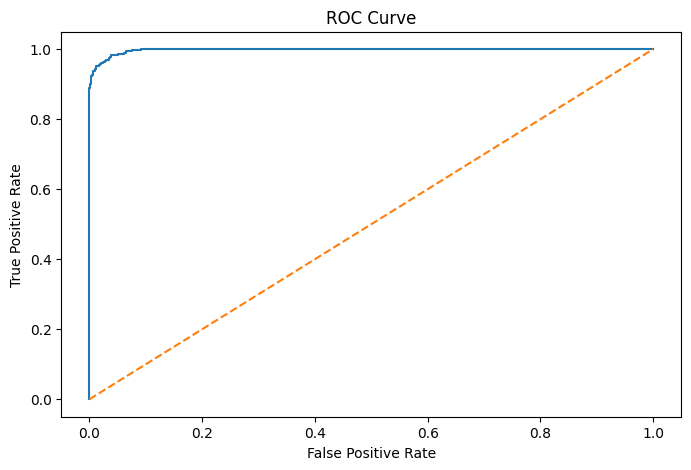

In [46]:
fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,5))

plt.plot(fpr,tpr)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

In [47]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance.sort_values(
    by='Coefficient',
    ascending=False,
    inplace=True
)

print(importance)

                    Feature  Coefficient
4          membership_years    11.298556
2            spending_score     3.385009
1             annual_income     2.286903
3        avg_purchase_value     0.097563
5  website_visits_per_month     0.050040
6         cart_abandon_rate     0.037497
0                       age    -0.020171


In [48]:
import joblib

joblib.dump(model, "logistic_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(kmeans, "kmeans_model.pkl")

['kmeans_model.pkl']

In [49]:
model = joblib.load("logistic_model.pkl")
scaler = joblib.load("scaler.pkl")
kmeans = joblib.load("kmeans_model.pkl")

In [50]:
new_customer = [[
    25,        # age
    50000,     # annual_income
    60,        # spending_score
    200,       # avg_purchase_value
    2,         # membership_years
    5,         # website_visits_per_month
    0.3        # cart_abandon_rate
]]

In [51]:
new_customer_scaled = scaler.transform(new_customer)

C:\Users\ashen\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [52]:
prediction = model.predict(new_customer_scaled)
probability = model.predict_proba(new_customer_scaled)[:,1]

print("Prediction:", prediction[0])
print("Purchase Probability:", probability[0])

Prediction: 0
Purchase Probability: 0.00014282932062152824


In [53]:
cluster = kmeans.predict(new_customer_scaled)

print("Customer Cluster:", cluster[0])

Customer Cluster: 3


In [54]:
print("=== CUSTOMER INSIGHT ===")

if prediction[0] == 1:
    print("Likely to PURCHASE")
else:
    print("Not likely to purchase")

print("Purchase Probability:", probability[0])
print("Customer Segment:", cluster[0])

=== CUSTOMER INSIGHT ===
Not likely to purchase
Purchase Probability: 0.00014282932062152824
Customer Segment: 3


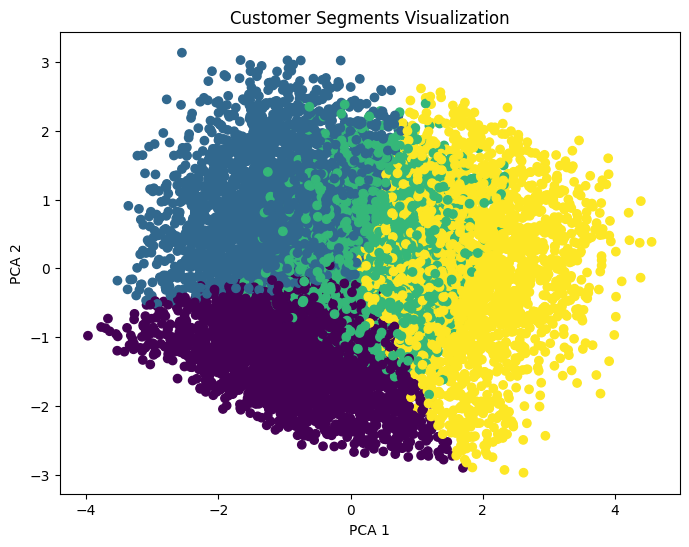

In [55]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df['Cluster'],
    cmap='viridis'
)

plt.title("Customer Segments Visualization")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

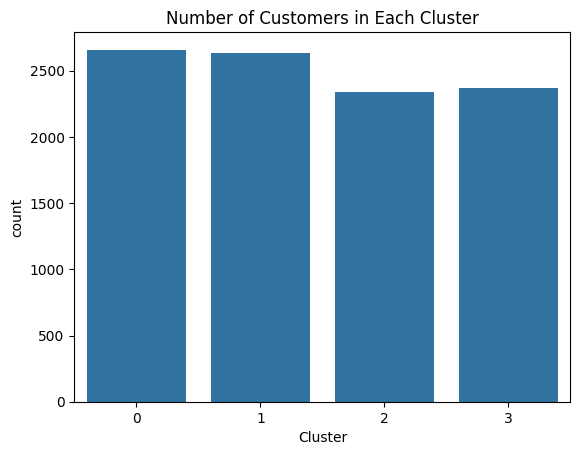

In [56]:
import seaborn as sns

sns.countplot(x=df['Cluster'])
plt.title("Number of Customers in Each Cluster")
plt.show()

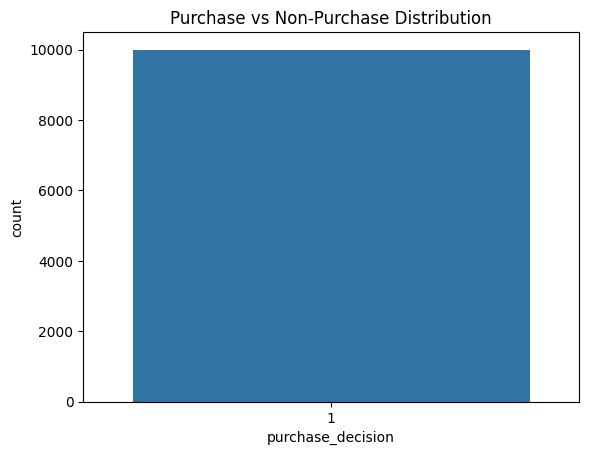

In [57]:
sns.countplot(x=df['purchase_decision'])
plt.title("Purchase vs Non-Purchase Distribution")
plt.show()

In [58]:
import pandas as pd

cluster_purchase = pd.crosstab(df['Cluster'], df['purchase_decision'])

print(cluster_purchase)

purchase_decision     1
Cluster                
0                  2658
1                  2634
2                  2342
3                  2366


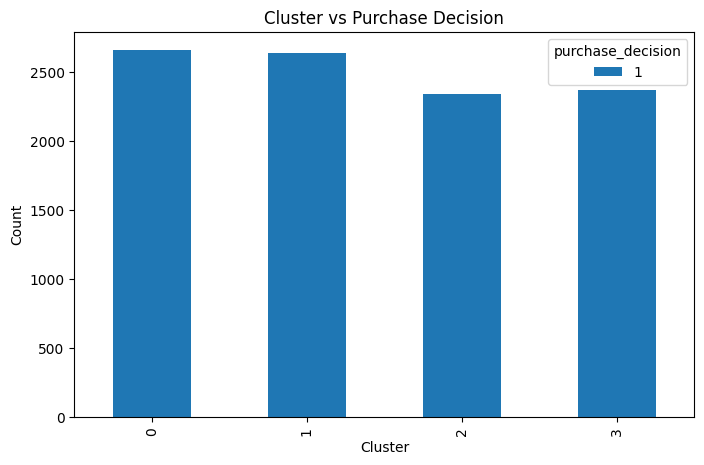

In [59]:
cluster_purchase.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Cluster vs Purchase Decision")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

In [60]:
cluster_summary = df.groupby('Cluster')[features].mean()

print(cluster_summary)

               age  annual_income  spending_score  avg_purchase_value  \
Cluster                                                                 
0        27.212942   73775.789315       50.554929           44.588194   
1        49.635915   68360.576689       23.388003           37.199875   
2        50.997865   66617.386849       75.686593           49.051336   
3        49.851226  138842.364328       57.483094           60.480423   

         membership_years  website_visits_per_month  cart_abandon_rate  
Cluster                                                                 
0                2.110986                 15.846501           0.489793  
1                7.827259                 15.618831           0.509115  
2                8.744663                 15.282237           0.505798  
3                7.057058                 15.524091           0.500719  


In [61]:
def label_cluster(row):
    if row['Cluster'] == 0:
        return "High Value Customer"
    elif row['Cluster'] == 1:
        return "Low Engagement Customer"
    elif row['Cluster'] == 2:
        return "Potential Customer"
    else:
        return "Other"

df['Cluster_Label'] = df.apply(label_cluster, axis=1)

print(df[['Cluster', 'Cluster_Label']].head())

   Cluster            Cluster_Label
0        1  Low Engagement Customer
1        1  Low Engagement Customer
2        3                    Other
3        2       Potential Customer
4        3                    Other


In [62]:
df.to_csv("final_customer_segments.csv", index=False)

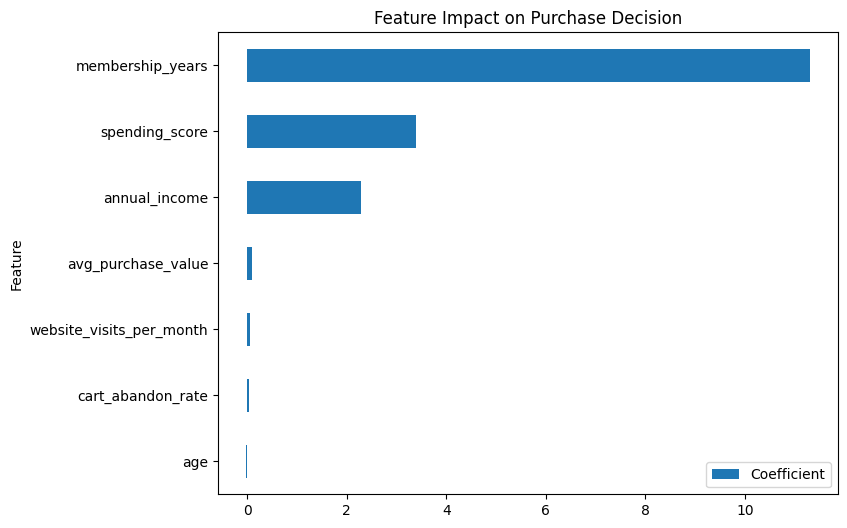

In [63]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance = importance.sort_values(by='Coefficient')

importance.plot(kind='barh', x='Feature', y='Coefficient', figsize=(8,6))
plt.title("Feature Impact on Purchase Decision")
plt.show()

In [64]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       991
           1       0.97      0.97      0.97      1009

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



In [65]:
def predict_customer(input_data):
    input_scaled = scaler.transform([input_data])
    
    purchase = model.predict(input_scaled)[0]
    prob = model.predict_proba(input_scaled)[0][1]
    cluster = kmeans.predict(input_scaled)[0]
    
    return {
        "Purchase Prediction": purchase,
        "Probability": prob,
        "Cluster": cluster
    }

In [66]:
result = predict_customer([25, 50000, 60, 200, 2, 5, 0.3])
print(result)

{'Purchase Prediction': np.int64(0), 'Probability': np.float64(0.00014282932062152824), 'Cluster': np.int32(3)}


C:\Users\ashen\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [67]:
# Save cluster summary
cluster_summary.to_csv("cluster_summary.csv")

# Save cluster vs purchase table
cluster_purchase.to_csv("cluster_purchase.csv")

# Save feature importance
importance.to_csv("feature_importance.csv", index=False)

In [68]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Captured:", sum(pca.explained_variance_ratio_[:2]))

Explained Variance Ratio: [0.27295565 0.18784182 0.14533915 0.14114676 0.1402577  0.09219379
 0.02026512]
Total Variance Captured: 0.46079747446726727


In [69]:
print(df['purchase_decision'].value_counts(normalize=True))

purchase_decision
1    1.0
Name: proportion, dtype: float64


In [70]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')

print("Cross Validation F1 Scores:", scores)
print("Mean F1 Score:", scores.mean())

Cross Validation F1 Scores: [0.97146402 0.9695084  0.97280593 0.96962182 0.97203232]
Mean F1 Score: 0.9710864989498967


In [71]:
import numpy as np

threshold = 0.4  # adjust based on business need

y_pred_custom = (y_prob >= threshold).astype(int)

from sklearn.metrics import f1_score

print("F1 Score (Custom Threshold):", f1_score(y_test, y_pred_custom))

F1 Score (Custom Threshold): 0.968780487804878


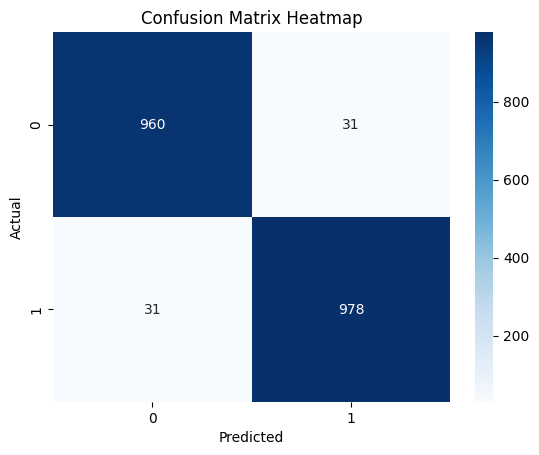

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [73]:
def marketing_strategy(cluster):
    if cluster == 0:
        return "Offer loyalty rewards and premium discounts"
    elif cluster == 1:
        return "Send re-engagement emails and offers"
    elif cluster == 2:
        return "Recommend personalized products"
    else:
        return "General marketing campaign"

df['Marketing_Strategy'] = df['Cluster'].apply(marketing_strategy)

print(df[['Cluster', 'Marketing_Strategy']].head())

   Cluster                    Marketing_Strategy
0        1  Send re-engagement emails and offers
1        1  Send re-engagement emails and offers
2        3            General marketing campaign
3        2       Recommend personalized products
4        3            General marketing campaign


In [74]:
df.to_csv("final_output_with_strategies.csv", index=False)

In [75]:
print("=== PROJECT SUMMARY ===")
print("Total Customers:", len(df))
print("Clusters Formed:", df['Cluster'].nunique())
print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

=== PROJECT SUMMARY ===
Total Customers: 10000
Clusters Formed: 4
Model Accuracy: 0.969
ROC AUC Score: 0.9976738115787379


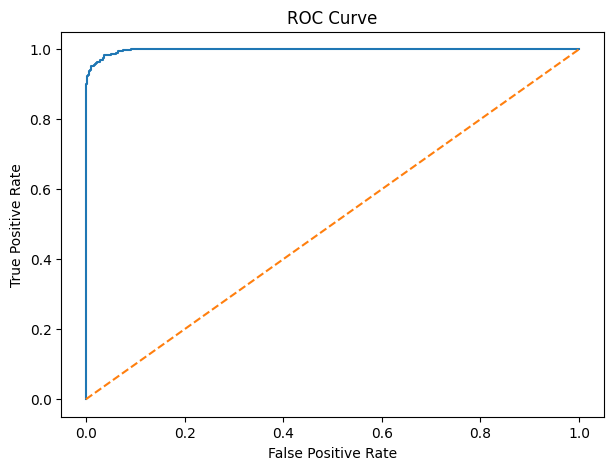

In [79]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()

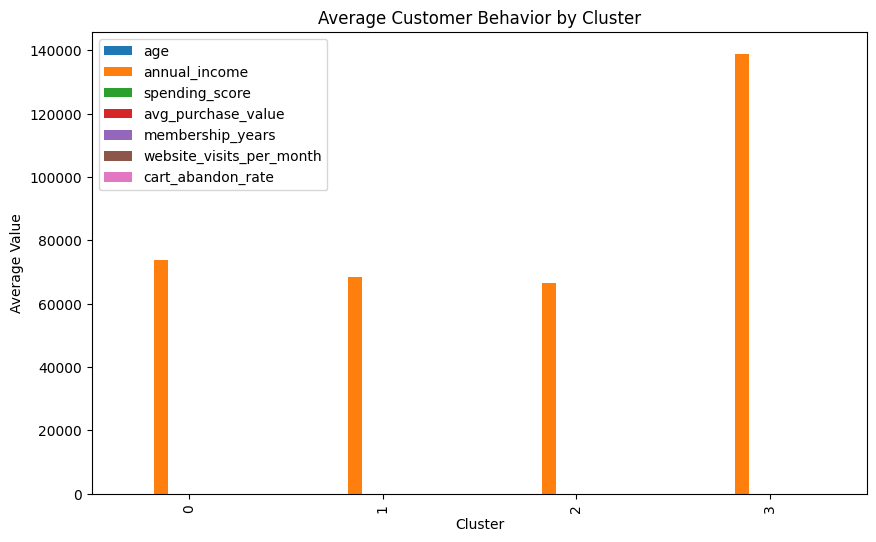

In [81]:
df.groupby('Cluster')[features].mean().plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Average Customer Behavior by Cluster")
plt.ylabel("Average Value")
plt.show()

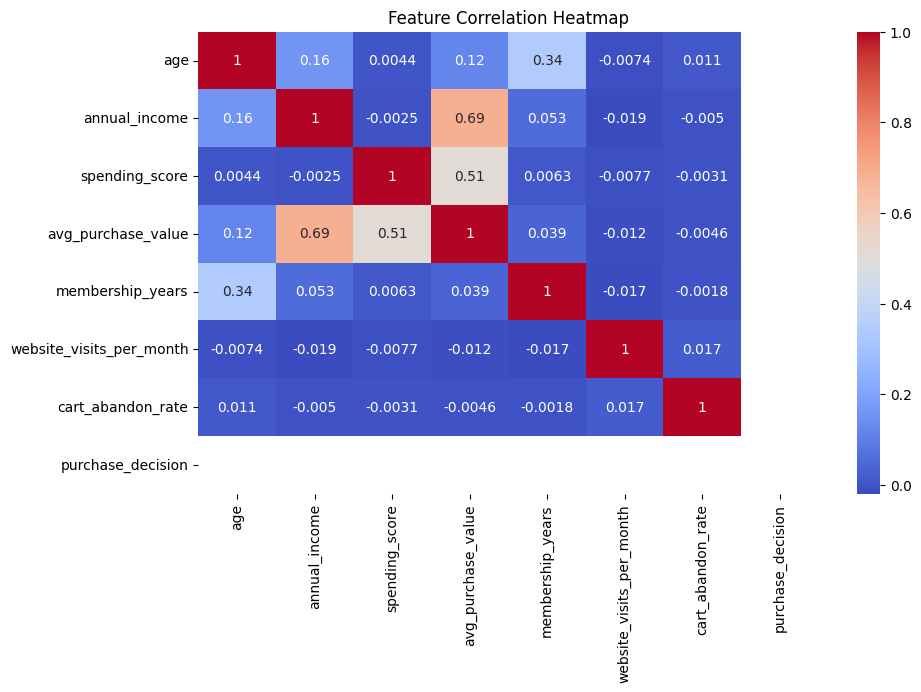

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(df[features + ['purchase_decision']].corr(), annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")

plt.show()

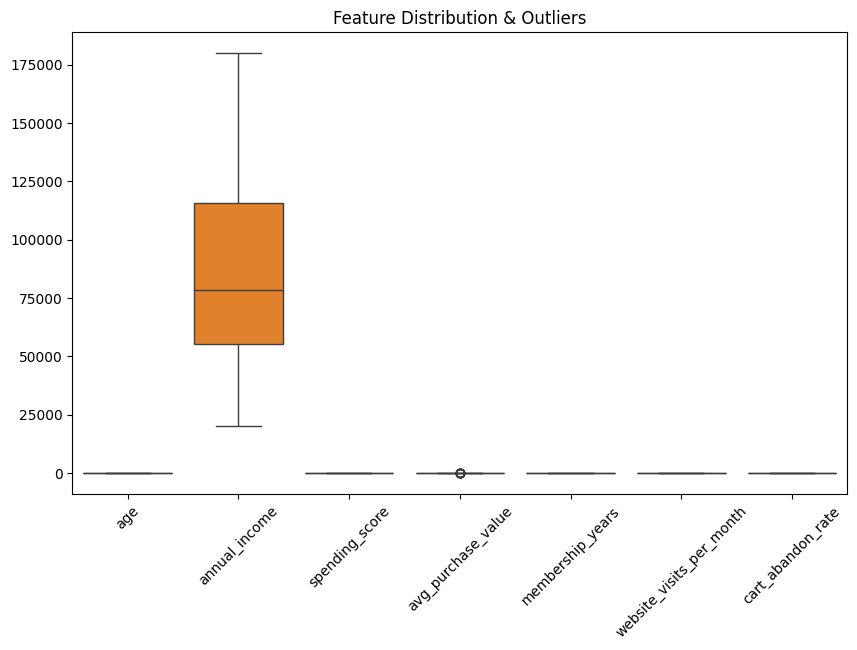

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(data=df[features])

plt.xticks(rotation=45)

plt.title("Feature Distribution & Outliers")

plt.show()

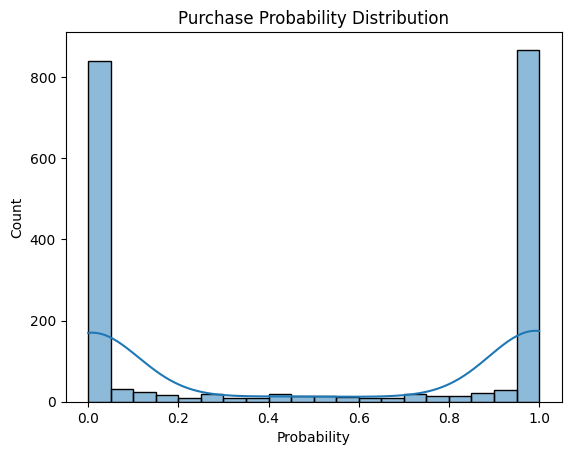

In [85]:
import seaborn as sns

sns.histplot(y_prob, bins=20, kde=True)
plt.title("Purchase Probability Distribution")
plt.xlabel("Probability")
plt.ylabel("Count")
plt.show()

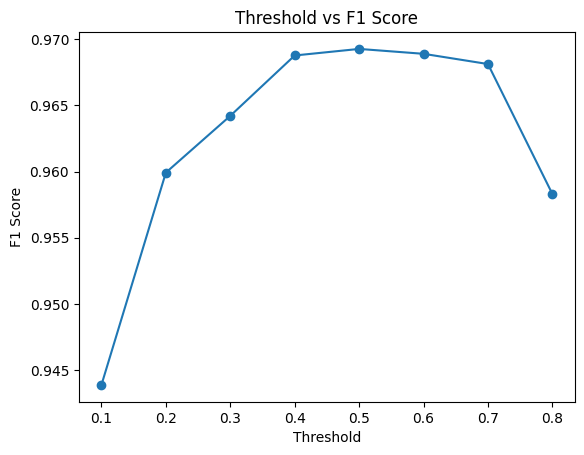

In [86]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.1)
f1_scores = []

for t in thresholds:
    preds = (y_prob >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds))

plt.plot(thresholds, f1_scores, marker='o')
plt.title("Threshold vs F1 Score")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.show()

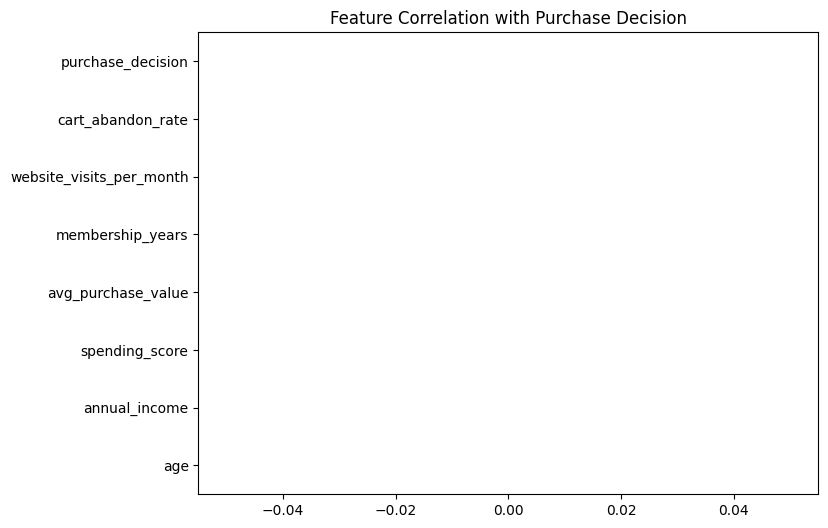

In [87]:
df[features + ['purchase_decision']].corr()['purchase_decision'].sort_values().plot(
    kind='barh',
    figsize=(8,6)
)

plt.title("Feature Correlation with Purchase Decision")
plt.show()

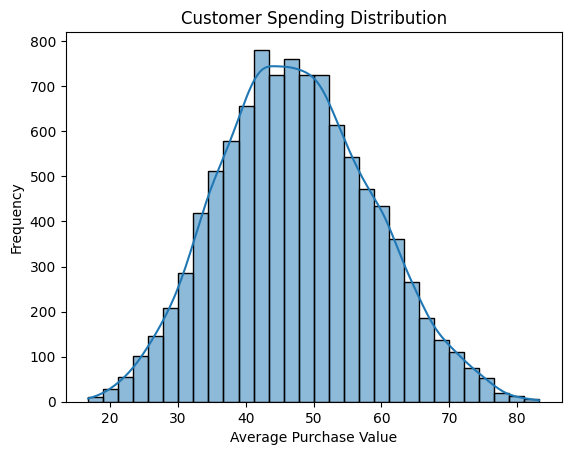

In [88]:
sns.histplot(df['avg_purchase_value'], bins=30, kde=True)

plt.title("Customer Spending Distribution")
plt.xlabel("Average Purchase Value")
plt.ylabel("Frequency")

plt.show()

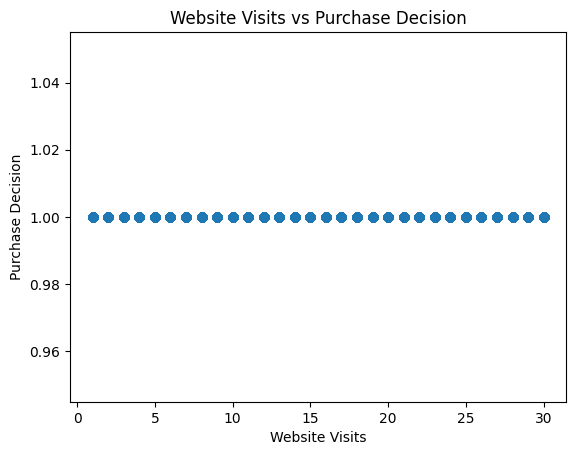

In [89]:
plt.scatter(df['website_visits_per_month'], df['purchase_decision'])

plt.title("Website Visits vs Purchase Decision")
plt.xlabel("Website Visits")
plt.ylabel("Purchase Decision")

plt.show()